# 1. Import Libraries

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load Data

In [65]:
train_data = pd.read_csv('Train.csv')
test_data = pd.read_csv('Test.csv')
meta_data = pd.read_csv('Meta.csv')

In [66]:
train_data.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [67]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
dtypes: int64(7), object(1)
memory usage: 2.4+ MB


In [68]:
test_data.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [69]:
meta_data.head()

,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


# EDA

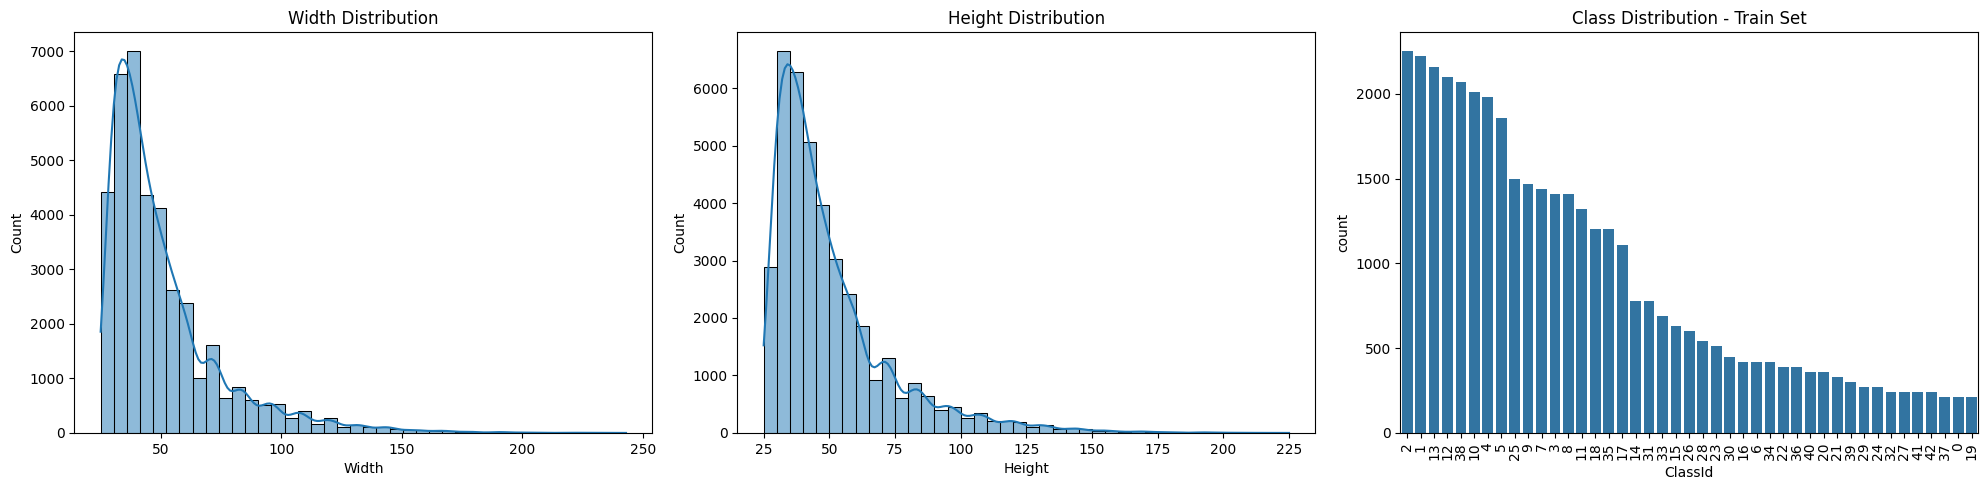

In [70]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# 1️⃣ Width Distribution
sns.histplot(train_data["Width"], bins=40, kde=True, ax=ax[0])
ax[0].set_title("Width Distribution")
ax[0].set_xlabel("Width")

# 2️⃣ Height Distribution
sns.histplot(train_data["Height"], bins=40, kde=True, ax=ax[1])
ax[1].set_title("Height Distribution")
ax[1].set_xlabel("Height")

# 3️⃣ Class Distribution
sns.countplot(
    data=train_data,
    x='ClassId',
    order=train_data['ClassId'].value_counts().index,
    ax=ax[2]
)
ax[2].set_title("Class Distribution - Train Set")
ax[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

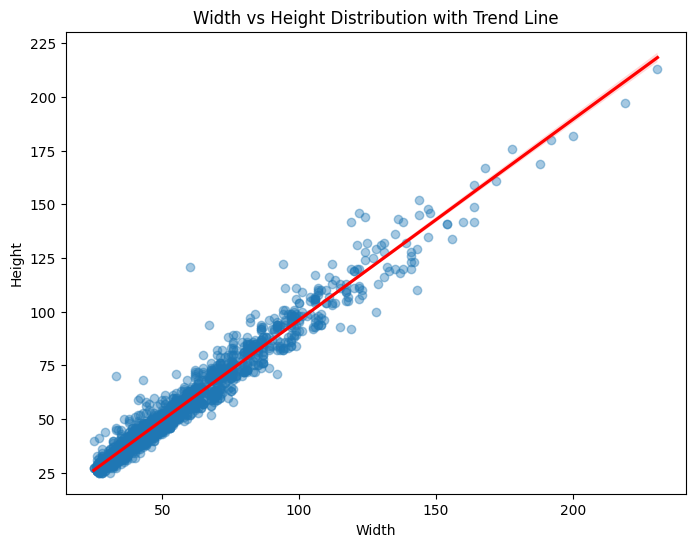

In [71]:
plt.figure(figsize=(8,6))

sample_data = train_data.sample(3000, random_state=42)

sns.regplot(
    data=sample_data,
    x='Width',
    y='Height',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title('Width vs Height Distribution with Trend Line')
plt.show()

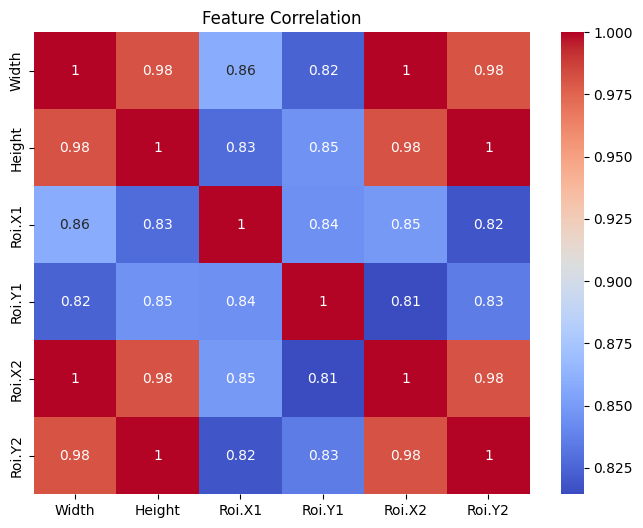

In [72]:
plt.figure(figsize=(8,6))

numeric_cols = ['Width','Height','Roi.X1','Roi.Y1','Roi.X2','Roi.Y2']

corr = train_data[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

# Load Train - Test

In [73]:
import cv2
import os

# Load Images Function
IMG_SIZE = 64

def load_images(df):

    images = []
    labels = []

    for _, row in df.iterrows():

        img_path = row['Path']

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img.astype("float32")
        images.append(img)
        labels.append(row['ClassId'])

    return np.array(images), np.array(labels)

In [74]:
X_train, y_train = load_images(train_data)
X_test, y_test = load_images(test_data)

print(X_train.shape)
print(X_test.shape)

(39209, 64, 64, 3)
(12630, 64, 64, 3)


# Train Validation Split

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# Load Dataset Properly

In [76]:
import tensorflow as tf
from keras import layers, models
from keras.utils import image_dataset_from_directory
from sklearn.metrics import confusion_matrix, classification_report

In [77]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Data Augmentation Layer

In [78]:
data_augmentation = tf.keras.Sequential([

    layers.RandomRotation(0.08),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.GaussianNoise(0.03)
])

# Modelling

In [79]:
#CNN Model
def build_cnn_model(input_shape=(64,64,3), num_classes=43):

    model = tf.keras.Sequential([

        layers.Input(shape=input_shape),

        data_augmentation,

        layers.Rescaling(1./255),

        layers.Conv2D(32,3,activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64,3,activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128,3,activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256,3,activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256,activation='relu'),
        layers.Dropout(0.5),
        
        layers.Dense(num_classes,activation='softmax')

    ])

    return model

In [80]:
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input

def build_mobilenet_model(input_shape=(64, 64, 3), num_classes=43):

    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)

    # augmentation
    x = data_augmentation(inputs)

    # preprocess mobilenet
    x = preprocess_input(x)

    # feature extractor
    x = base_model(x, training=False)

    # classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    return model

In [81]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Training Function
def train_model(model, train_ds, val_ds, epochs=30):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
        
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stop, reduce_lr]
    )

    return history

In [82]:
print(X_train.shape)
print(y_train.shape)
print(y_train[:10])

(31367, 64, 64, 3)
(31367,)
[12  5 12 13 18 38 12  4 15  4]


In [83]:
# Training Models

models = {
    'CNN': build_cnn_model(),
    'MobileNetV2': build_mobilenet_model()
}

histories = {}
results = {}

for name, model in models.items():

    print(f"\nTraining {name}")

    history = train_model(model, train_ds, val_ds)

    print(f"\nEvaluating {name}")

    test_loss, test_acc = model.evaluate(test_ds, verbose=1)

    histories[name] = history
    
    results[name] = {
        'Test Loss': test_loss,
        'Test Accuracy': test_acc
    }

print('\n------- Model Result -------')

for name, metrics in results.items():
    print(f"\n{name}")
    print(f"Test Loss : {metrics['Test Loss']:.4f}")
    print(f"Test Accuracy : {metrics['Test Accuracy']:.4f}")

C:\Users\AtikahDR\AppData\Local\Temp\ipykernel_10848\2041056874.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(



Training CNN
Epoch 1/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 2129s 265ms/step - accuracy: 0.4710 - loss: 1.9195 - val_accuracy: 0.8893 - val_loss: 0.3734 - learning_rate: 3.0000e-04
Epoch 2/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 484s 247ms/step - accuracy: 0.8000 - loss: 0.6528 - val_accuracy: 0.9719 - val_loss: 0.0987 - learning_rate: 3.0000e-04
Epoch 3/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 486s 248ms/step - accuracy: 0.8821 - loss: 0.3818 - val_accuracy: 0.9852 - val_loss: 0.0464 - learning_rate: 3.0000e-04
Epoch 4/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 484s 247ms/step - accuracy: 0.9138 - loss: 0.2866 - val_accuracy: 0.9930 - val_loss: 0.0252 - learning_rate: 3.0000e-04
Epoch 5/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 484s 247ms/step - accuracy: 0.9291 - loss: 0.2387 - val_accuracy: 0.9958 - val_loss: 0.0161 - learning_rate: 3.0000e-04
Epoch 6/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 494s 252ms/step - accuracy: 0.9412 - loss: 0.2051 - val_accuracy: 0.9950 - val_loss: 0.0154 - learning_rate: 3.0000e-04
Epoch 7/30
19

# Confusion Matrix

In [84]:
# get true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

for name, model in models.items():

    print(f"\n---- {name} ----")

    # prediction
    y_pred_prob = model.predict(test_ds, verbose=0)

    y_pred = np.argmax(y_pred_prob, axis=1)

    # classification report
    print(classification_report(y_true, y_pred, zero_division=0))


---- CNN ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.99      1.00      0.99       720
           2       1.00      1.00      1.00       750
           3       1.00      0.99      0.99       450
           4       1.00      0.99      0.99       660
           5       0.99      0.99      0.99       630
           6       1.00      0.99      1.00       150
           7       0.99      1.00      0.99       450
           8       1.00      1.00      1.00       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       0.99      0.99      0.99       420
          12       1.00      0.99      0.99       690
          13       0.99      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       1.00      0.99      1.00       210
          16       1.00      1.00      1.00       150
          17

790/790 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step


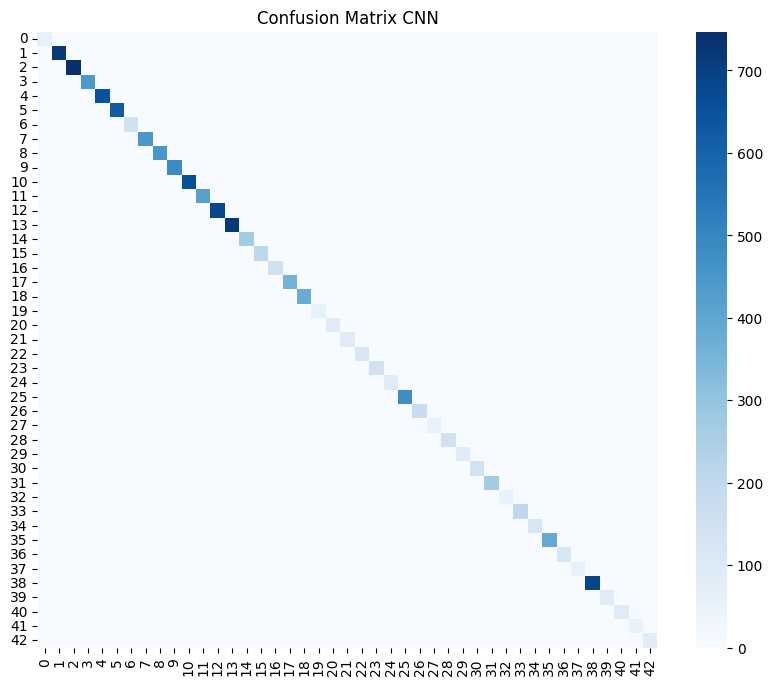

790/790 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step


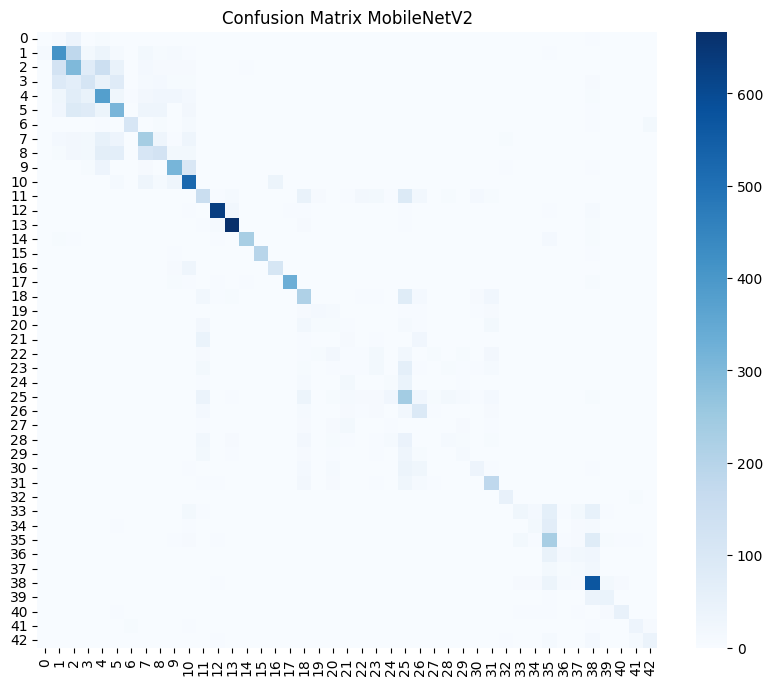

In [85]:
# Confusion Matrix
for name, model in models.items():
    y_pred = model.predict(test_ds)
    y_pred = np.argmax(y_pred, axis=1)
    y_true = np.concatenate([y for x,y in test_ds], axis=0)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap='Blues')
    plt.title(f'Confusion Matrix {name}')
    plt.show()

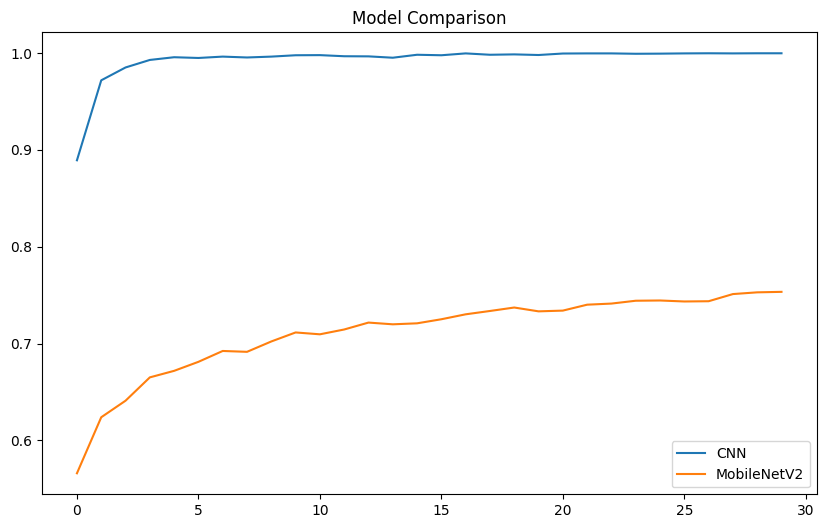

In [86]:
# Learning Curve
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.legend()
plt.title("Model Comparison")
plt.show()

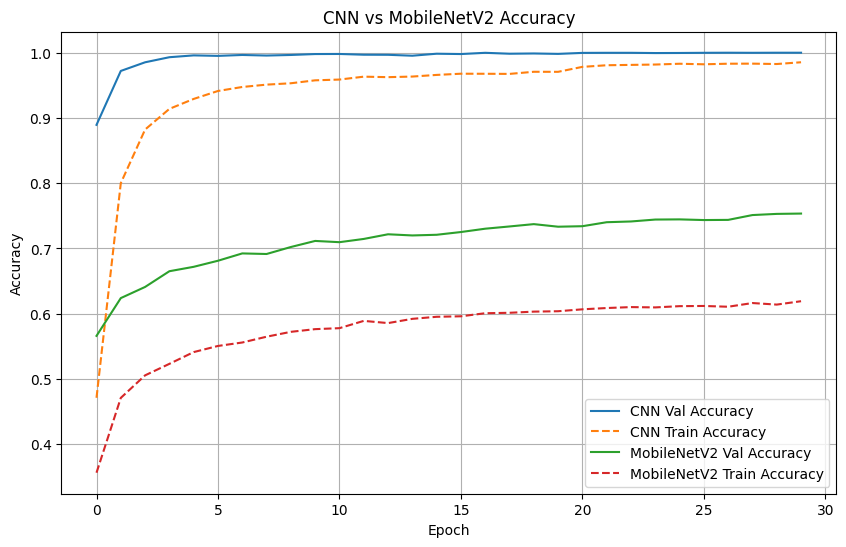

In [87]:
#Accuracy Comparison Graph
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'{name} Val Accuracy')
    plt.plot(history.history['accuracy'], linestyle='--', label=f'{name} Train Accuracy')

plt.title('CNN vs MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

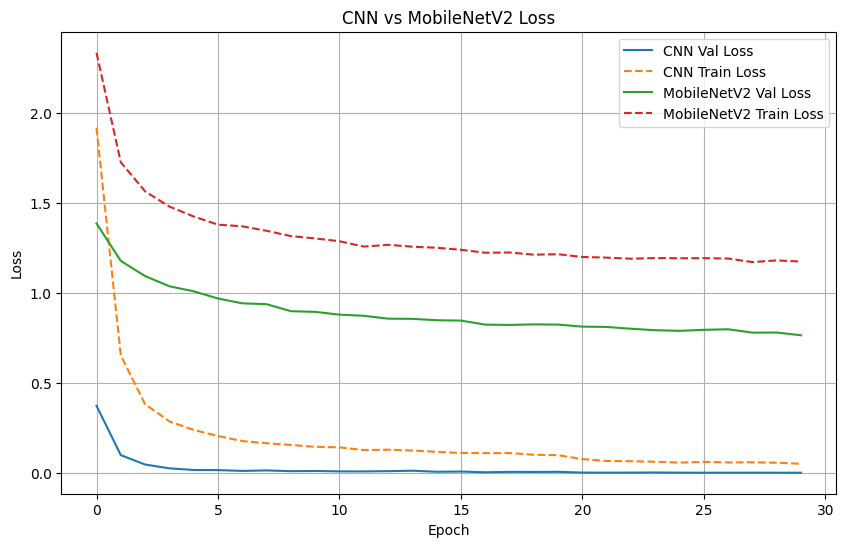

In [88]:
#Loss Comparison Graph
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=f'{name} Val Loss')
    plt.plot(history.history['loss'], linestyle='--', label=f'{name} Train Loss')

plt.title('CNN vs MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

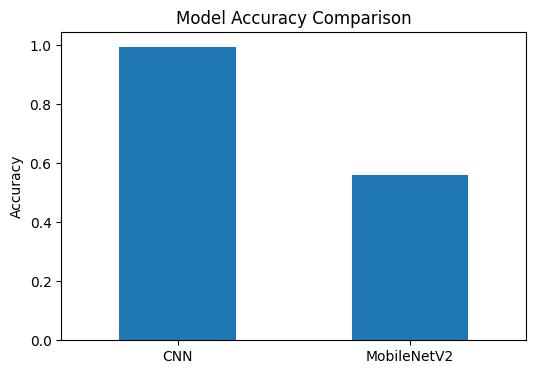

In [89]:
# Accuracy Bar Comparison
results_df = pd.DataFrame(results).T

results_df['Test Accuracy'].plot(
    kind='bar',
    figsize=(6,4),
    title='Model Accuracy Comparison'
)

plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.show()

In [91]:
# Save Model
os.makedirs('Models', exist_ok=True)

for name, model in models.items():
    model.save(f'Models/{name}.keras')